In [1]:
from src.state import InputState, Context
from src.graph.workflow import build_graph
from IPython.display import Image, display

from dotenv import load_dotenv

load_dotenv()

c:\Users\moism\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

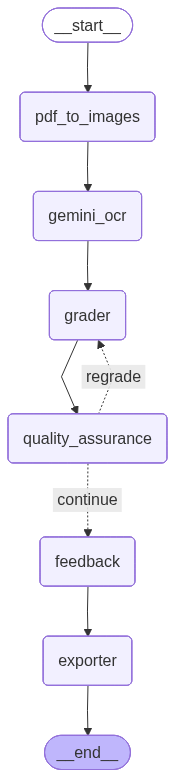

In [2]:
graph = build_graph(
        model="gpt-5",
        temperature=0.0,
    )

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
final_state = graph.invoke(
	input=InputState({
		"student_id": "student_02",
		"dpi": 300,
		"max_pages": 10,
		"exam_file": "Exam Java alternative 2025.txt",
		"rubric_file": "java_criteria.txt",
	}),
	context=Context(),
    )

Converted 10 pages.
Extracted text from 10 pages.

Grading exam...
Grading completed.

Performing quality assurance on grading results...
Quality assurance completed.

QA cleared. Proceeding to feedback.

Generating feedback for the student...
Feedback generation completed.

Exporting results...
Results exported.


In [4]:
print("\nFinal state:")
final_state.pop("messages")
for k, v in final_state.items():
	print(f"- {k}: {v}")


Final state:
- extract_dir: data\output\student_02\extracted_text
- export_dir: data\output\student_02\grading_results
- log_path: data\output\student_02\messages_log.log
- grader_results: ['Total Mark: 55.5\n\nEvaluations:\n\tQuestion 1.1:\n\tAwarded Points: 1.5\n\tJustification: Partial. Student wrote: "means that Java is a Langauge that works with diffirent components architectures". This suggests platform/architecture independence but does not mention compilation to bytecode or running on the JVM, which is required for full credit.\n\n\tQuestion 1.2:\n\tAwarded Points: 0.0\n\tJustification: No answer provided. The line "2-" is blank; missing any mention of the Web/Internet enabling distributed, network-based, platform-independent programming.\n\n\tQuestion 1.3:\n\tAwarded Points: 3.0\n\tJustification: Correct. Student wrote: "POP emphisis on the procuders (Code of the data OOP emphysis on the classes & objects" capturing that POP focuses on procedures/functions while OOP focuses o

In [3]:
from src.utils import io
import logging

logging.shutdown()

stream = graph.stream(
	input=InputState({
		"student_id": "student_03",
		"dpi": 300,
		"max_pages": 10,
		"exam_file": "Exam Java alternative 2025.txt",
		"rubric_file": "java_criteria.txt",
	}),
	context=Context(),
     stream_mode="updates",
     subgraphs=True,
     version="v2"
        )

for chunk in stream:
     if chunk["ns"]:
          node, values = list(chunk["data"].items())[0]
          print(f"\n- Subgraph[{node}] update\n  Messages:")
          for message in values.get("messages", []):
               message.content = io.truncate_text(message.content, limit=20)
               message.pretty_print()
     else:
          print(f"\n* Root[{list(chunk['data'].keys())[0]}] update\n" + "-" * 100)

Converted 10 pages.

* Root[pdf_to_images] update
----------------------------------------------------------------------------------------------------
Extracted text from 10 pages.

* Root[gemini_ocr] update
----------------------------------------------------------------------------------------------------

Grading exam...

- Subgraph[model] update
  Messages:
================================== Ai Message ==================================
Tool Calls:
  fuzzy_keyword_match (call_KwBPkoxaldQPucB0wsLEEfpf)
 Call ID: call_KwBPkoxaldQPucB0wsLEEfpf
  Args:
    student_answer: light wieght
    accepted_terms: ['Lightweight', 'Light-weight', 'Light weight']
    threshold: 0.7
  fuzzy_keyword_match (call_ke1Yd2I8IqaY2GG0cHlhl25E)
 Call ID: call_ke1Yd2I8IqaY2GG0cHlhl25E
  Args:
    student_answer: inter face
    accepted_terms: ['Interfaces', 'Inter faces', 'Inter-faces']
    threshold: 0.7
  fuzzy_keyword_match (call_EFj9amGlvUTO79S0rdbI0XLU)
 Call ID: call_EFj9amGlvUTO79S0rdbI0XLU
  Args:
  